In [1]:
%load_ext autoreload
%autoreload 2

import os
import multiprocessing

from qdots_qll.utils.povms import sigmas_povm
import jax
import numpy as np
import jax.numpy as jnp
import qutip as qt

# os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count={}".format(
#     multiprocessing.cpu_count()
# )


import tomllib
from qdots_qll.exp_design import (
    RandomExpDesign,
    MaxDetFimExpDesign,
    MaxTraceFimExpDesign,
)
from qdots_qll.run import Run, initial_run_from_config
from qdots_qll.smc import SMCUpdater, SMC_run
from qdots_qll.resamplers import LWResampler
from qdots_qll.stop_conditions import TerminationChecker

from qdots_qll.distributions import (
    est_cov,
    est_mean,
    initialize_particle_locations,
    initialize_weights,
)
from qdots_qll.models.models_scratch_for_drafting import (
    SingleQDot3Params,
)
import joblib
import logging
from datetime import datetime
from qdots_qll.utils.generate_initial_state import max_entangled_dm_vec
from pprint import pformat, pprint
import argparse
from jax_tqdm import loop_tqdm
import matplotlib.pyplot as plt

In [2]:
with open("jobs/one_dot.toml", "rb") as f:
    config = tomllib.load(f)


logging.info(pformat(config["run"]))


number_of_runs = config["run"]["number_of_runs"]
number_of_runs_compilation = config["run_for_compilation"]["number_of_runs"]

print(number_of_runs)
print(number_of_runs_compilation)


ground_state_qdot = jnp.array(qt.ket2dm(qt.basis(2, 0))).flatten()
model = SingleQDot3Params(POVM_array=jnp.array(sigmas_povm))


seed = config["run"]["seed"]


key = jax.random.PRNGKey(seed=seed)


key, subkey = jax.random.split(key)


# print(initial_runs_compilation)
# keys = jax.random.split(key, number_of_runs)
true_pars = jnp.array(config["run"]["true_parameters"])


exp_design_dict = {
    "random": RandomExpDesign(0.01, 40),
    "maxdetfim": MaxDetFimExpDesign(0.01, 40, 20, lr=0.5),
    "maxtracefim": MaxTraceFimExpDesign(0.01, 40, 20, lr=0.5),
}

exp_design = exp_design_dict[config["run"]["exp_design"]]


resampler = LWResampler()


smcupdater = SMCUpdater(
    model=model,
    exp_design=exp_design,
    resampler=resampler,
    initial_state=ground_state_qdot,
    true_pars=true_pars,
    number_exp_repetitions=1,
)

20
5


In [3]:
key, subkey = jax.random.split(key)
run_0 = (
    lambda key: initial_run_from_config(
        key,
        model,
        config["run"],
    )
)(subkey)


stopper = TerminationChecker(config["run"]["max_iterations"])

In [4]:
keys = jax.random.split(subkey, number_of_runs)
initial_runs = (
    jax.vmap(
        lambda key: initial_run_from_config(
            key,
            model,
            config["run"],
        )
    )
)(keys)

In [6]:
exp_design

MaxDetFimExpDesign(t_min=0.01, t_max=40, sgd_iter=20, lr=0.5)

In [5]:
# n = config["run"]["max_iterations"]
n = 150


@loop_tqdm(n)
def f_fori(i, r_obj):
    r_obj = smcupdater.step(r_obj)
    return r_obj


result = (lambda run_0: jax.lax.fori_loop(0, n, f_fori, run_0))(run_0)

  0%|          | 0/150 [00:00<?, ?it/s]

In [16]:
particles_locations = result.particles_locations
weights = result.weights

In [17]:
result

Run(
  iteration=i32[],
  key=u32[2],
  time=f32[],
  weights=f32[500],
  particles_locations=f32[500,3],
  times_array=f32[10000],
  estimates_array=f32[10000,3],
  cov_array=f32[10000,3,3],
  max_iterations=i32[],
  min_iterations=i32[],
  std_threshold=f32[]
)

In [18]:
est_mean(particles_locations, weights)

Array([ 0.35683233,  0.10621706, -0.38715178], dtype=float32)

In [19]:
true_pars

Array([ 0.35833 ,  0.053851, -0.333695], dtype=float32)

In [23]:
m = model

# jax.vmap(lambda t: )

# True parameters. FIM

In [57]:
m = model

times = jnp.linspace(0, 60, 500)

fim_times = jax.vmap(lambda t: m.fim(true_pars, t, ground_state_qdot))(times)

det_times = jax.vmap(lambda a: jnp.linalg.det(a))(fim_times[:, 0:, 0:])

In [58]:
det_times_all = det_times

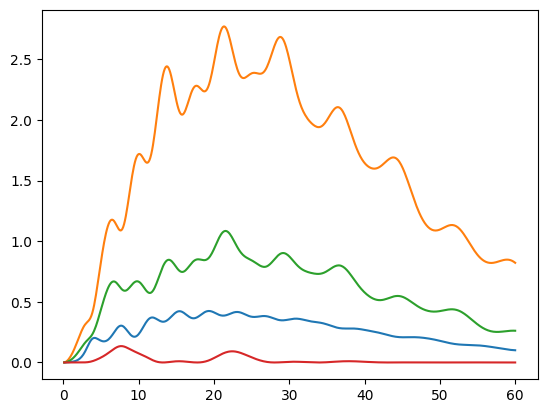

In [59]:
for i in range(3):
    plt.plot(times, fim_times[:, i, i])

plt.plot(times, det_times)
# plt.yscale('log')

In [60]:
jax.scipy.special.kl_div(fim_times.T, fim_times.T).shape

(3, 3, 500)

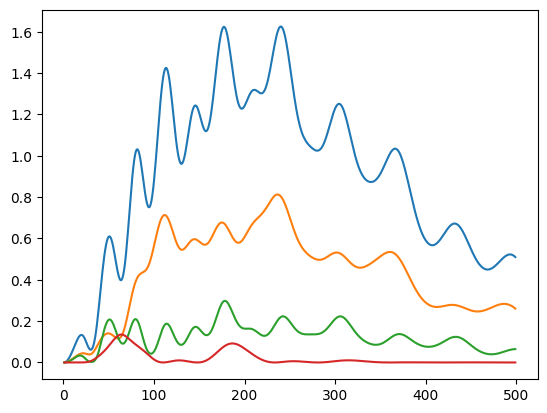

In [61]:
plt.plot(jax.scipy.special.kl_div(fim_times[:, 0, 0], fim_times[:, 1, 1]))
plt.plot(jax.scipy.special.kl_div(fim_times[:, 2, 2], fim_times[:, 1, 1]))

plt.plot(jax.scipy.special.kl_div(fim_times[:, 0, 0], fim_times[:, 2, 2]))

plt.plot(det_times)

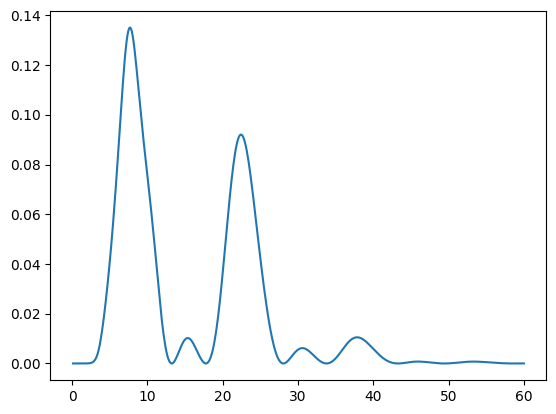

In [62]:
plt.plot(times, det_times)

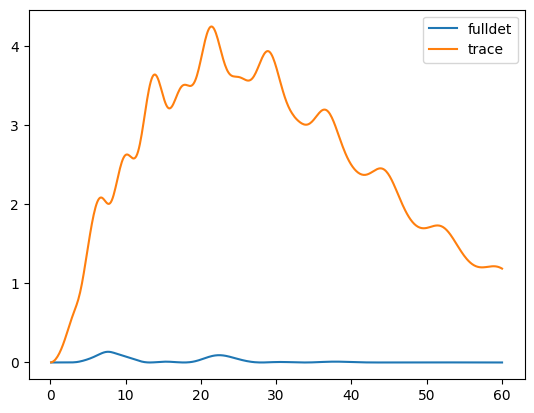

In [118]:
m = SingleQDot3Params(sigmas_povm[0:] * 1)

times = jnp.linspace(0, 60, 500)

fim_times = jax.vmap(lambda t: m.fim(true_pars, t, ground_state_qdot))(times)

det_times = jax.vmap(lambda a: jnp.linalg.det(a))(fim_times[:, 0:, 0:])

trace_times = jax.vmap(lambda a: jnp.trace(a))(fim_times[:, 0:, 0:])
trace_times_all = jax.vmap(lambda a: jnp.trace(a))(fim_times[:, 0:, 0:])

# for i in range(3):
#     plt.plot(times, fim_times[:, i, i], label=i)

# plt.plot(times, det_times)
plt.plot(times, det_times_all, label="fulldet")

plt.plot(times, trace_times, label="trace")
plt.legend()
plt.show()
# plt.yscale('

# One chooses X measurement

In [63]:
(sigmas_povm[0:2] * 3).sum(0)

array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])

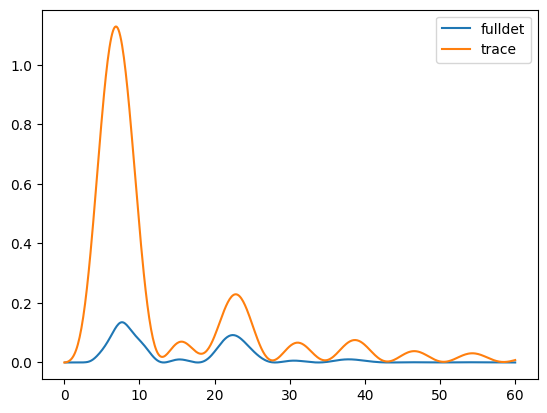

In [73]:
m = SingleQDot3Params(sigmas_povm[0:2] * 3)

times = jnp.linspace(0, 60, 500)

fim_times = jax.vmap(lambda t: m.fim(true_pars, t, ground_state_qdot))(times)

det_times = jax.vmap(lambda a: jnp.linalg.det(a))(fim_times[:, 0:, 0:])

trace_times = jax.vmap(lambda a: jnp.trace(a))(fim_times[:, 0:, 0:])
# for i in range(3):
#     plt.plot(times, fim_times[:, i, i], label=i)

# plt.plot(times, det_times)
plt.plot(times, det_times_all, label="fulldet")

plt.plot(times, trace_times, label="trace")
plt.legend()
plt.show()
# plt.yscale('log')

# One chooses Y measurement

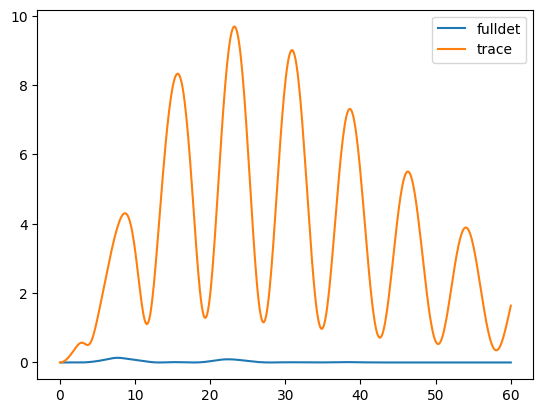

In [74]:
m = SingleQDot3Params(sigmas_povm[2:4] * 3)

times = jnp.linspace(0, 60, 500)

fim_times = jax.vmap(lambda t: m.fim(true_pars, t, ground_state_qdot))(times)

det_times = jax.vmap(lambda a: jnp.linalg.det(a))(fim_times[:, 0:, 0:])

trace_times = jax.vmap(lambda a: jnp.trace(a))(fim_times[:, 0:, 0:])
# for i in range(3):
#     plt.plot(times, fim_times[:, i, i], label=i)

# plt.plot(times, det_times)
plt.plot(times, det_times_all, label="fulldet")

plt.plot(times, trace_times, label="trace")
plt.legend()
plt.show()
# plt.yscale('log')

# One choose Z measurement

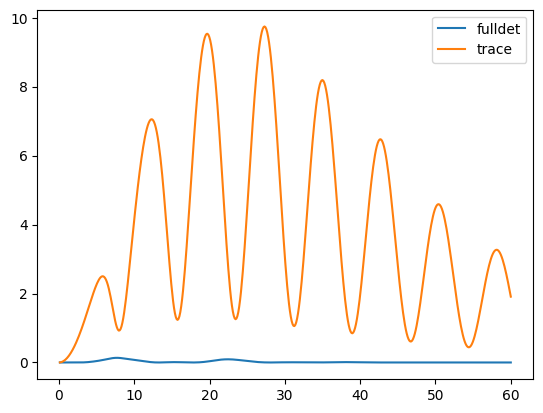

In [77]:
m = SingleQDot3Params(sigmas_povm[4:6] * 3)
times = jnp.linspace(0, 60, 500)

fim_times = jax.vmap(lambda t: m.fim(true_pars, t, ground_state_qdot))(times)

det_times = jax.vmap(lambda a: jnp.linalg.det(a))(fim_times[:, 0:, 0:])

trace_times = jax.vmap(lambda a: jnp.trace(a))(fim_times[:, 0:, 0:])
# for i in range(3):
#     plt.plot(times, fim_times[:, i, i], label=i)

# plt.plot(times, det_times)
plt.plot(times, det_times_all, label="fulldet")

plt.plot(times, trace_times, label="trace")
plt.legend()
plt.show()

# Let's study how the trace changes when we have a bad estimate


In [100]:
particles_locations
m = SingleQDot3Params(sigmas_povm[0:] * 1)

In [101]:
jax.vmap(lambda t: m.fim(particle, t, ground_state_qdot))(times)

NameError: name 'particle' is not defined

In [102]:
fim_particles = jax.vmap(
    lambda particle: jax.vmap(lambda t: m.fim(particle, t, ground_state_qdot))(
        times
    )
)(particles_locations)

In [103]:
est_mean(particles_locations, weights)

Array([ 0.35683233,  0.10621706, -0.38715178], dtype=float32)

In [104]:
fim_mean_pars = jax.vmap(
    lambda t: m.fim(
        est_mean(particles_locations, weights), t, ground_state_qdot
    )
)(times)

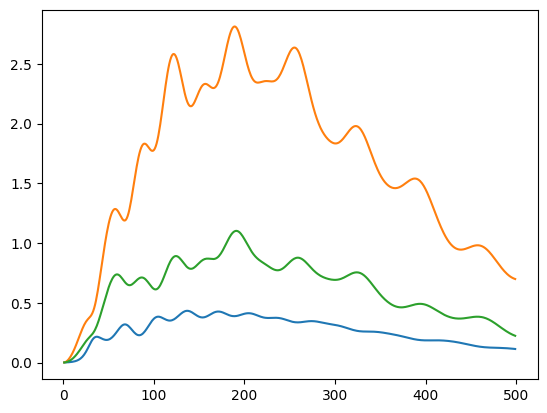

In [105]:
for i in range(3):
    plt.plot(fim_mean_pars[:, i, i])

In [98]:
fim_mean_pars

Array([[[           nan,            nan,            nan],
        [           nan,            nan,            nan],
        [           nan,            nan,            nan]],

       [[ 1.1784064e-03, -9.5370918e-04,  5.7703763e-04],
        [-9.5370918e-04,  7.7185698e-04, -4.6700874e-04],
        [ 5.7703763e-04, -4.6700874e-04,  2.8256161e-04]],

       [[ 1.4361265e-03, -2.3572152e-03,  1.4287522e-03],
        [-2.3572152e-03,  3.8690628e-03, -2.3451112e-03],
        [ 1.4287522e-03, -2.3451112e-03,  1.4214156e-03]],

       ...,

       [[ 1.7264085e-01, -4.0501589e-01,  1.7943044e-01],
        [-4.0501589e-01,  9.5016831e-01, -4.2094427e-01],
        [ 1.7943044e-01, -4.2094427e-01,  1.8648705e-01]],

       [[ 1.5648460e-01, -4.0524471e-01,  1.8362586e-01],
        [-4.0524471e-01,  1.0494533e+00, -4.7553182e-01],
        [ 1.8362586e-01, -4.7553182e-01,  2.1547461e-01]],

       [[ 1.4059225e-01, -4.0184355e-01,  1.8570572e-01],
        [-4.0184355e-01,  1.1485572e+00, -5.30787

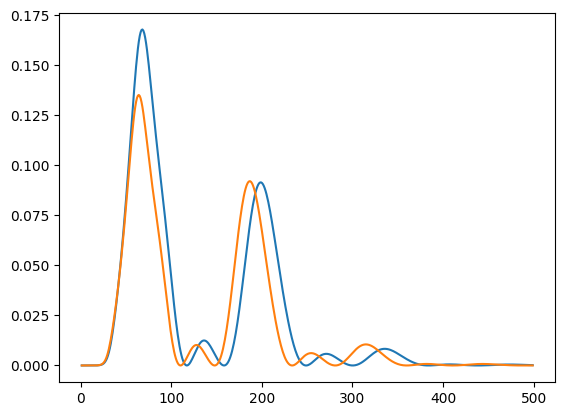

In [110]:
plt.plot(jax.vmap(lambda a: jnp.linalg.det(a))(fim_mean_pars))
plt.plot(det_times_all)

In [111]:
mean_fim = jnp.einsum("ijkl, i", fim_particles, weights)

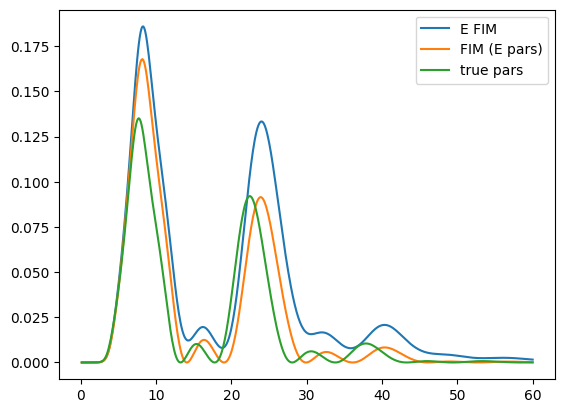

In [122]:
plt.plot(times, jax.vmap(lambda a: jnp.linalg.det(a))(mean_fim), label="E FIM")
plt.plot(
    times,
    jax.vmap(lambda a: jnp.linalg.det(a))(fim_mean_pars),
    label="FIM (E pars)",
)

plt.plot(times, det_times_all, label="true pars")
plt.legend()
plt.show()

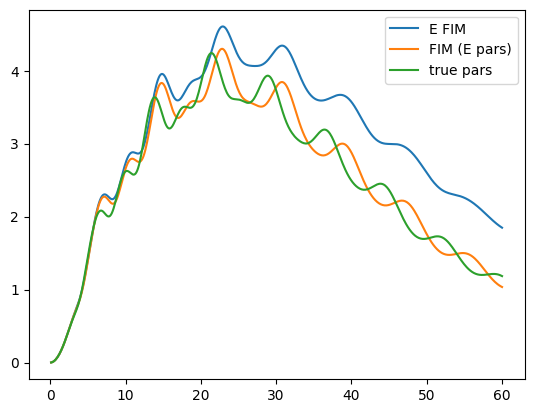

In [125]:
plt.plot(times, jax.vmap(lambda a: jnp.trace(a))(mean_fim), label="E FIM")
plt.plot(
    times,
    jax.vmap(lambda a: jnp.trace(a))(fim_mean_pars),
    label="FIM (E pars)",
)

plt.plot(times, trace_times_all, label="true pars")
plt.legend()


# plt.plot(times, jax.vmap(lambda a: jnp.linalg.det(a))(mean_fim), label="E FIM")
# plt.plot(times, jax.vmap(lambda a: jnp.linalg.det(a))(fim_mean_pars), label="FIM (E pars)")

# plt.plot(times, det_times_all, label="true pars")


plt.show()